In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [61]:
import pandas as pd
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


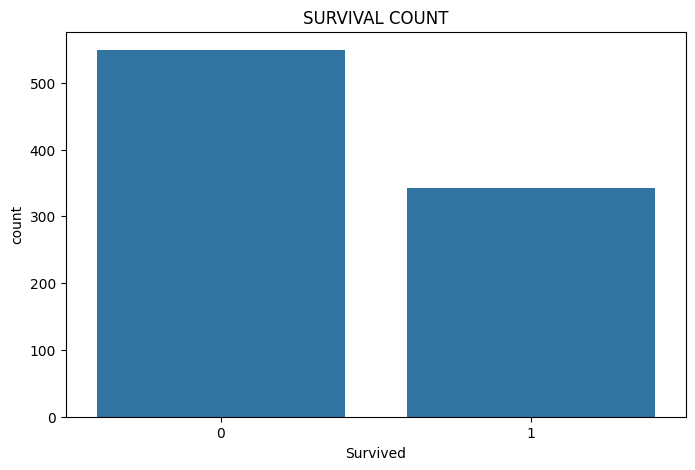

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x= 'Survived')
plt.title('SURVIVAL COUNT')
plt.show()

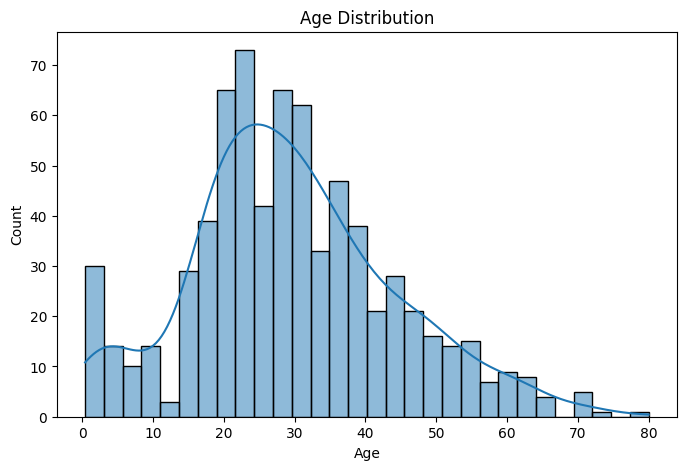

In [63]:
plt.figure(figsize=(8, 5))
sns.histplot(data = df, x = 'Age', kde= True, bins = 30)
plt.title('Age Distribution')
plt.show()

In [64]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']


In [65]:
X.head()


,Pclass,Sex,Age,SibSp,Fare,Embarked
0,3,male,22.0,1,7.2500,S
1,1,female,38.0,1,71.2833,C
2,3,female,26.0,0,7.9250,S
3,1,female,35.0,1,53.1000,S
4,3,male,35.0,0,8.0500,S


In [66]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [67]:
# Defining column types
num_cols = ['Age', 'SibSp', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']


In [68]:
# pipline for this
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler' , StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [69]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [70]:
full_pipeline = Pipeline([
    ('preprocessor' , preprocessor),
    ('variance_thresh', VarianceThreshold(threshold=0.01)),
    ('pca', PCA(n_components=5)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [72]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('variance_thresh', VarianceThreshold(threshold=0.01)),
                ('pca', PCA(n_components=5)),
                ('classifier', LogisticRegression(max_iter=1000))])

In [73]:
y_pred = full_pipeline.predict(X_test)

In [74]:
acc = accuracy_score(y_test, y_pred)
print("✅ Model accuracy after preprocessing:", round(acc * 100, 2), "%")


✅ Model accuracy after preprocessing: 78.77 %


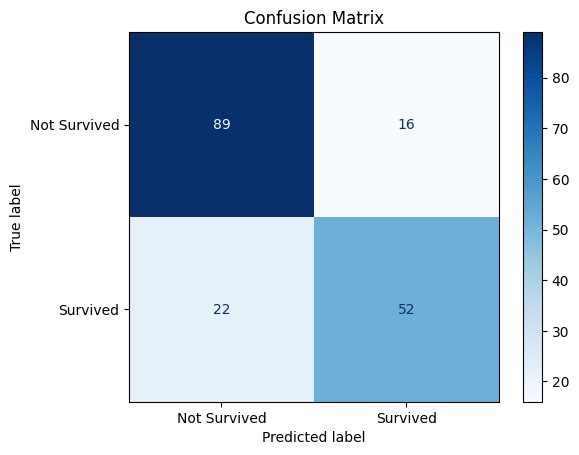

In [75]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
